# MI of receptors activity for realistic curves.

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import entr
import itertools

# --- 1. Define General Parameters ---
Nr = 3  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 2,3
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.


### 1. Generate, and binning of activity curves
#### 1.1 Homo and Hetero pentamers:

In [ ]:
def Popen(c,epsilon,Ko,Kc):
    """
    epsilon: energy difference between the open and closed state, without ligand. typically <0
    Kc: ligand dissociation constant when channel in closed state
    Ko: open-state dissociation constant : Ko_ = Ko exp(beta -epsilon/5)
    c: ligand concentration
    """
    c = c + 1e-18
    return (1+c/Ko)**5/((1+c/Ko)**5+np.exp(-epsilon)*(1+c/Kc)**5)
def Pmin(epsilon):
    return 1/(1+np.exp(-epsilon))
def Pmax(epsilon,Ko,Kc):
    return 1/(1+(Ko/Kc)**5*np.exp(-epsilon))
def PopenNorm(c,epsilon,Ko,Kc):
    return (Popen(c,epsilon,Ko,Kc) - Pmin(epsilon))/(Pmax(epsilon,Ko,Kc) - Pmin(epsilon))

def PmaxHetero(epsilon,Kos,Kcs):
    return 1/(1+np.prod([Ko/Kc for Ko,Kc in zip(Kos,Kcs)]) * np.exp(-epsilon))
def PoHetero(c,epsilon,Kos,Kcs):
    """
    Kos and Kcs are both list of Kc, and Ko. reapeating values will increase the number of monomer of a type.
    """
    return np.prod([1 + c/Ko for Ko in Kos],axis=0)/(np.prod([1+c/Ko for Ko in Kos],axis=0) + np.exp(-epsilon)*np.prod([1+c/Kc for Kc in Kcs],axis=0))
def PoHeteroNorm_vectorized(c, epsilon, Kos, Kcs):
    """
    Vectorized calculation of the Normalized Open Probability for Hetero-pentamers.
    Uses the MWC state ratio form: P = 1 / (1 + L_iso * R)
    """
    # 1. Isomerization constant L (Closed/Open equilibrium at c=0)
    # epsilon shape: (L, Nr, 1, 1) -> L_iso: (L, Nr, 1)
    L_iso = np.exp(-epsilon).squeeze(-1)
    
    # 2. State Ratios R(c) = Prod_subunits [ (1+c/Kc) / (1+c/Ko) ]
    # Calculates the relative stability of Closed vs Open state for all c
    # Shape: (L, Nr, Nc)
    R_c = np.prod((1 + c / Kcs) / (1 + c / Kos), axis=2)
    
    # 3. Limiting Ratio R(inf) = Prod(Ko/Kc)
    # This defines the saturation limit as c -> infinity
    # Kos/Kcs shape: (L, Nr, 5, 1) -> prod axis 2 -> (L, Nr, 1)
    # We DO NOT squeeze the last dim so it broadcasts with L_iso (L, Nr, 1)
    R_inf = np.prod(Kos / Kcs, axis=2)
    
    # 4. Calculate Probabilities: P = 1 / (1 + L * R)
    P_c = 1.0 / (1.0 + L_iso * R_c)
    P_min = 1.0 / (1.0 + L_iso)       # At c=0, R=1, shape (L, Nr, 1)
    P_max = 1.0 / (1.0 + L_iso * R_inf) # Shape (L, Nr, 1)
    
    # 5. Normalize
    # Use np.divide with 'where' to handle cases where P_max == P_min (flat response)
    delta_P = P_max - P_min
    return np.divide(P_c - P_min, delta_P, where=(delta_P != 0), out=np.zeros_like(P_c))

def PoHeteroNorm(c,epsilon,Kos,Kcs):
    return (PoHetero(c,epsilon,Kos,Kcs) - Pmin(epsilon))/(PmaxHetero(epsilon,Kos,Kcs) - Pmin(epsilon))
def generate_discrete_curve(epsilon, Kos, Kcs, Nc, c_min, c_max, Na):
    """
    Generates a discrete activation curve from the continuous Popen model.

    Args:
        epsilon, Ko, Kc: Parameters for the Popen function.
        Nc (int): Number of concentration bins.
        c_min (float): Minimum concentration for binning.
        c_max (float): Maximum concentration for binning.
        Na (int): Number of activity bins.

    Returns:
        np.array: A 1D array of length Nc containing the discrete
                  activity curve (e.g., [0, 0, 1] for Na=2, Nc=3).
    """
    
    # --- Concentration Bins (Logarithmic) ---
    # Create Nc+1 bin edges from c_min to c_max
    c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
    
    # Get Nc bin representative centers (geometric mean)
    c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
    
    # --- Activity Bins (Linear) ---
    # Create Na+1 bin edges from 0 to 1
    a_edges = np.linspace(0, 1, Na + 1)
    a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
    a_centers[0] = 0.
    a_centers[-1] = 1.
    
    # --- Discretization ---
    # 1. Get the continuous Popen value at each concentration center
    #continuous_values = PopenNorm(c_centers, epsilon, Ko, Kc)
    continuous_values = PoHeteroNorm(c_centers, epsilon, Kos, Kcs)
    
    # 2. Digitize these values into bins
    discrete_curve = np.digitize(continuous_values, a_edges)
    return c_edges,a_centers[discrete_curve-1]
def response_to_index(response_vector, Na):
    """
    Maps a response vector [a0, a1, ..., aNr-1] to a unique integer index.
    This treats the vector as a number in base Na.
    """
    index = 0
    power = 1
    for activity_level in response_vector:
        index += activity_level * power
        power *= Na
    return int(index)
def response_to_index_vectorized(response_matrix, Na):
    """
    Maps a matrix of response vectors to unique integer indices.
    
    Args:
        response_matrix: (N_events, Nr) array. Each row is one event [r0, r1, r2].
        Na: Number of activity bins (base).
    Returns:
        indices: (N_events,) array of unique integers.
    """
    Nr = np.asarray(response_matrix).shape[1]
    # Powers array: [1, Na, Na^2, ...]
    powers = Na ** np.arange(Nr)
    # Dot product broadcasting to get unique index for each row
    return np.sum(response_matrix * powers, axis=1)

def index_to_response(index, Nr, Na):
    """Decodes unique index back to vector [r0, r1, r2...]"""
    response = np.zeros(Nr, dtype=int)
    current = index
    for i in range(Nr):
        response[i] = current % Na
        current //= Na
    return response

# ----------------------------------------------------------------
# -----------Uncomment to perform tests on the indexing-----------
# ----------------------------------------------------------------
# Write the response of three receptors. They must be inside activity bins
#y_index = [[0,Na//2, Na-1]]
#y = [a_centers[i] for i in y_index]
#print([np.digitize(y_val,a_centers)-1 for y_val in y])
#print(y)
#print(response_to_index(y_index[0],Na))
#print(response_to_index_vectorized(y_index,Na))
#print(index_to_response(response_to_index(y_index[0],Na),Nr=3,Na=Na))

def generate_activity_matrix(epsilon, Kos, Kcs, c_centers, a_edges):
    """
    Generates the discrete activity matrix for a set of ligands.
    
    Args:
        epsilon: (L, Nr, 5)
        Kos:     (L, Nr, 5)
        Kcs:     (L, Nr, 5)
        c_centers: (Nc,)
        a_edges:   (Na+1,)
        
    Returns:
        discrete_A: Integer array of shape (L, Nr, Nc)
    """
    L, Nr, penta = epsilon.shape
    Nc = len(c_centers)
    
    # --- 1. Prepare Input Shapes for Broadcasting ---
    
    # c: Add axes for L, Nr, and Subunit -> (1, 1, 1, Nc)
    c_grid = c_centers[np.newaxis, np.newaxis, np.newaxis, :]
    
    # Kos, Kcs: Add axis for Concentration -> (L, Nr, 5, 1)
    Kos_grid = Kos[:, :, :, np.newaxis]
    Kcs_grid = Kcs[:, :, :, np.newaxis]
    
    # epsilon: All 5 subunits share the same epsilon for the complex global transition.
    # We take the first value and add axes -> (L, Nr, 1, 1)
    eps_grid = epsilon[:, :, 0][:, :, np.newaxis, np.newaxis]
    
    # --- 2. Calculate Continuous Response ---
    continuous_A = PoHeteroNorm_vectorized(c_grid, eps_grid, Kos_grid, Kcs_grid)
    
    # --- 3. Discretize ---
    # Clip to ensure numerical stability doesn't push values < 0 or > 1
    continuous_A = np.clip(continuous_A, 0, 1)
    
    # Digitize using inner edges as thresholds
    discrete_A = np.digitize(continuous_A, a_edges[1:-1])
    
    return discrete_A

def analyze_activity_histogram_and_mi(discrete_A, Na):
    """
    Computes the histogram of activity vectors and the Mutual Information.
    
    Formula: MI = log(N_total) - Sum( (M_A / N_total) * log(M_A) )
    
    Args:
        discrete_A: Array of shape (L, Nr, Nc).
        Na: Number of activity bins.
    """
    L, Nr, Nc = discrete_A.shape
    
    # 1. Define N_total (Total number of events 3L in toy model, L*Nc here)
    N_total = L * Nc
    
    # 2. Reshape the matrix to list of events (N_total, Nr)
    # Transpose to (L, Nc, Nr) so the receptor vector is the last dimension
    # Reshape flattens L and Nc into one dimension
    events_matrix = discrete_A.transpose(0, 2, 1).reshape(-1, Nr)
    
    # 3. Convert each event vector to a unique index
    indices = response_to_index_vectorized(events_matrix, Na)
    
    # 4. Compute Multiplicity M_A (Histogram)
    # The maximum possible index is Na^Nr
    max_state_index = Na ** Nr
    
    # np.bincount is a fast histogram for integers
    # M_all[idx] = count of how many times state 'idx' appeared
    M_all = np.bincount(indices, minlength=max_state_index)
    
    # 5. Filter to keep only observed states (where M_A > 0)
    observed_mask = M_all > 0
    
    # The Multiplicities (M_A) of observed states
    M_A = M_all[observed_mask]
    
    # The indices of observed states
    observed_indices = np.where(observed_mask)[0]
    
    # 6. Compute Probabilities P(A)
    P_A = M_A / N_total
    
    # 7. Compute Mutual Information
    # Term 1: log(N_total)
    term1 = np.log(N_total)
    
    # Term 2: Sum_A [ (M_A / N_total) * log(M_A) ]
    term2 = np.sum( P_A * np.log(M_A) )
    
    MI = term1 - term2
    
    return MI, M_A, P_A

In [23]:
def plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs = None,label=None,color='b'):
    """
    Generates a two-panel plot to illustrate the binning of the
    continuous Popen curve into a discrete activation curve.

    Left Panel: Smooth Popen curve with binning grid.
    Right Panel: Discretized step-plot of the activation curve.
    """
    
    # --- Get Binning Info ---
    c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
    c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
    c_labels = [f'$c_{{{i}}}$' for i in range(Nc)]
    
    a_edges = np.linspace(0, 1, Na + 1)
    a_values = np.arange(Na)
    
    # --- plot instances ---
    if figaxs is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)
    else:
        fig,(ax1,ax2) = figaxs
    grid_style = {'color': 'gray', 'linestyle': ':', 'linewidth': .5, 'alpha': 0.7}

    # --- Generate Plot Data ---
    
    # 1. Smooth curve data (for left panel)
    x_plot = np.logspace(np.log10(c_min), np.log10(c_max), 500)
    #y_plot = PopenNorm(x_plot, epsilon, Ko, Kc)
    y_plot = PoHeteroNorm(x_plot, epsilon, Kos, Kcs)

    if label is None:
        ax1.plot(x_plot, y_plot, label=f'P(c, $\\epsilon={epsilon}, K_o={Ko}, K_c={Kc}$)')
    else:
        ax1.plot(x_plot, y_plot, label=label,color=color)
    ax1.set_xscale('log')

    # Add binning grid
    for t in c_edges:
        ax1.axvline(x=t, **grid_style)
    for t in a_edges[1:-1]:
        ax1.axhline(y=t, **grid_style)

    # Aesthetics
    ax1.set_xlabel('Concentration $c$')
    ax1.set_ylabel(r'$p_\text{o}(c)$')
    if c_centers.__len__()<=10:
        ax1.set_xticks(c_centers, c_labels)
    else:
        denom = c_centers.__len__()//10
        ax1.set_xticks(c_centers[0::denom], c_labels[0::denom])
    ax1.xaxis.minorticks_off()
    #ax1.set_yticks(a_edges[1:-1], [f'Threshold = {t:.2f}' for t in a_edges[1:-1]])
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xlim(c_min, c_max)
    ax1.legend(loc='center left', bbox_to_anchor=(-.0, 1.2))
    

    # 2. Discrete curve data (for right panel)
    x2, activity_curve = generate_discrete_curve(epsilon, Kos, Kcs, Nc, c_min, c_max, Na)
    
    # Create x and y data for the step plot
    x_step = c_edges
    y_step = np.append(activity_curve, activity_curve[-1])

    # --- Create Plots ---

    # === Plot 2: Binned Version ===
    if label is None:
        ax2.plot(x_step, y_step, label='discretized', drawstyle='steps-post')
    else: 
        ax2.plot(x_step, y_step, label='discretized: '+label, drawstyle='steps-post',color=color)
    ax2.set_xscale('log')

    # Add binning grid
    for t in c_edges:
        ax2.axvline(x=t, **grid_style)
    for t in a_edges[1:-1]:
        ax2.axhline(y=t, **grid_style)

    # Add text to show the binned values
    #for k in range(Nc):
    #    ax2.text(c_centers[k], 0.5, f'Bin $c_{{{k}}}$\n$a(c)={activity_curve[k]}$', 
    #             ha='center', va='center', fontsize=12)

    # Aesthetics
    ax2.set_xlabel('Concentration $c$')
    ax2.set_ylabel(r'$p_\text{o}(c)$')
    #ax2.set_xticks(c_centers, c_labels)
    if c_centers.__len__()<=10:
        ax2.set_xticks(c_centers, c_labels)
    else:
        denom = c_centers.__len__()//10
        ax2.set_xticks(c_centers[0::denom], c_labels[0::denom])
    ax2.xaxis.minorticks_off()
    ax2.set_xlim(c_min, c_max)
    ax2.set_ylim(-0.1, 1.1)
    ax2.legend(loc='center left', bbox_to_anchor=(-.0, 1.2))

    # --- Show Plot ---
    plt.tight_layout()

epsilon = -1.00 | Ko = [0.5, 0.5, 0.5, 0.5, 0.5] | Kcs = [10.0, 10.0, 10.0, 10.0, 10.0]
epsilon = -1.00 | Ko = [0.5, 0.5, 2.0, 2.0, 2.0] | Kcs = [10.0, 10.0, 5.0, 5.0, 5.0]
epsilon = -1.00 | Ko = [2.0, 2.0, 2.0, 2.0, 2.0] | Kcs = [5.0, 5.0, 5.0, 5.0, 5.0]


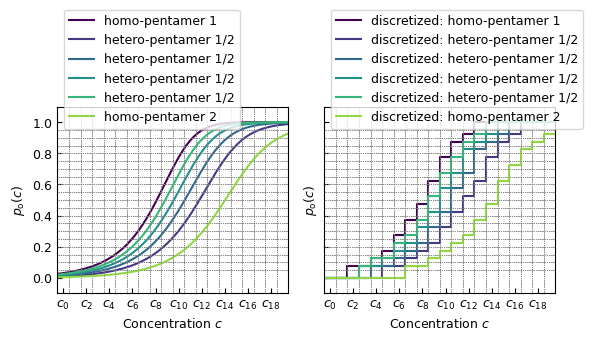

In [48]:
from matplotlib import colormaps



figaxs = plt.subplots(ncols=2,figsize=(6,3.5),sharey=True)
fig,(ax1,ax2) = figaxs

#params = np.array([[-1.0,0.5,10.],[-1.0,1.5,10.],[-1.0,2.,5.]])
params = [[-1.0,0.5,10.],[-1.0,2.,5.]]
colors = [colormaps['viridis'](i/6.) for i in range(6)]

epsilon,Kos,Kcs = params[0][0],[params[0][1]] * 5, [params[0][2]] * 5
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')

plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='homo-pentamer 1',color=colors[0])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*1 + [params[1][1]]*4, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[1])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*2 + [params[1][1]]*3, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[2])
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*3 + [params[1][1]]*2, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[3])

epsilon,Kos,Kcs = params[0][0],[params[0][1]]*4 + [params[1][1]]*1, [params[0][2]]*2 + [params[1][2]]*3
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='hetero-pentamer 1/2',color=colors[4])

epsilon,Kos,Kcs = params[1][0],[params[1][1]] * 5, [params[1][2]] * 5
plot_binning_comparison(epsilon, Kos, Kcs, Nc, c_min, c_max, Na,figaxs=figaxs,label='homo-pentamer 2',color=colors[5])
print(f'epsilon = {epsilon:.2f} | Ko = {Kos} | Kcs = {Kcs}')
#plot_binning_comparison(epsilon, Ko, Kc, 20, c_min, c_max, 20)

#fig.savefig('hetero_homo_binning_20.svg',bbox_inches='tight')


#### 1.2 Generate activity curves
We first generate the curves by drawing physical parameters, and then look at how it transcripts in the histogram of the activity.

In [106]:
# draw random parameters # 0 is homo1, 2 is homo2, 3 is hetero
# Ko << Kc
L = 100
Nr = 3
Kcs = np.zeros((L,Nr,5),dtype=float)
Kos = np.zeros((L,Nr,5),dtype=float)
epsilon = np.zeros((L,Nr,5),dtype=float)
for l in range(L):
    # select Kc1 \in [0, 10], Ko1 \in [0,Kc1] -> Ko1<=Kc1
    Kc1 = np.random.random() * 10
    Ko1 = np.random.random() * Kc1
    # select Kc2 \in [Kc1, Kc1+10] Kc2>=Kc1 & Ko2 \in [0,Ko1] Ko2<=Ko1 | Ko2<=Kc2
    Kc2 = Kc1 + np.random.random()*10
    Ko2 = np.random.random()*Ko1
    # generate three receptors:
    Kcs[l,0,:] = [Kc1] * 5 # Homo-1
    Kcs[l,1,:] = [Kc1] * 3 + [Kc2] * 2 # Hetero
    Kcs[l,2,:] = [Kc2] * 5 # Homo-2

    Kos[l,0,:] = [Ko1] * 5 # Homo-1
    Kos[l,1,:] = [Ko1] * 3 + [Ko2] * 2 # Hetero
    Kos[l,2,:] = [Ko2] * 5 # Homo-2

    # epsilon \in [-10,0] -> epsilon <<1    
    eps1 = -1#np.random.random() * -10
    eps2 = -1#np.random.random() * -10
    epsilon[l,0,:] = [eps1] * 5
    epsilon[l,2,:] = [eps2] * 5
    epsilon[l,1,:] = [eps1] * 3 + [eps2]*2

array([[[ 4.91147747,  4.91147747,  4.91147747,  4.91147747,
          4.91147747],
        [ 4.91147747,  4.91147747,  4.91147747, 11.94187232,
         11.94187232],
        [11.94187232, 11.94187232, 11.94187232, 11.94187232,
         11.94187232]],

       [[ 4.79267483,  4.79267483,  4.79267483,  4.79267483,
          4.79267483],
        [ 4.79267483,  4.79267483,  4.79267483,  6.71215634,
          6.71215634],
        [ 6.71215634,  6.71215634,  6.71215634,  6.71215634,
          6.71215634]],

       [[ 7.75113968,  7.75113968,  7.75113968,  7.75113968,
          7.75113968],
        [ 7.75113968,  7.75113968,  7.75113968,  9.3489429 ,
          9.3489429 ],
        [ 9.3489429 ,  9.3489429 ,  9.3489429 ,  9.3489429 ,
          9.3489429 ]],

       ...,

       [[ 0.96552711,  0.96552711,  0.96552711,  0.96552711,
          0.96552711],
        [ 0.96552711,  0.96552711,  0.96552711,  1.50534425,
          1.50534425],
        [ 1.50534425,  1.50534425,  1.50534425,  1.505344

#### 2. Indexing the response
We want to compute the mutual information $ MI(\mathcal{A},\mathcal{L}) $. Which requires ton compute the following probability distributions: $p_(\mathcal{A})

In [102]:
A = generate_activity_matrix(epsilon = epsilon,Kcs = Kcs, Kos = Kos, c_centers = c_centers, a_edges = a_edges)
print(A.shape)

(100, 3, 3)


---------------HOMO 1---------------
Kcs = [0.84168154 0.84168154 0.84168154 0.84168154 0.84168154]
Kos = [0.25022899 0.25022899 0.25022899 0.25022899 0.25022899]
eps = [-1. -1. -1. -1. -1.]
---------------HETERO ---------------
Kcs = [0.84168154 0.84168154 0.84168154 4.94385804 4.94385804]
Kos = [0.25022899 0.25022899 0.25022899 0.00950047 0.00950047]
eps = [-1. -1. -1. -1. -1.]
---------------HOMO 2---------------
Kcs = [4.94385804 4.94385804 4.94385804 4.94385804 4.94385804]
Kos = [0.00950047 0.00950047 0.00950047 0.00950047 0.00950047]
eps = [-1. -1. -1. -1. -1.]


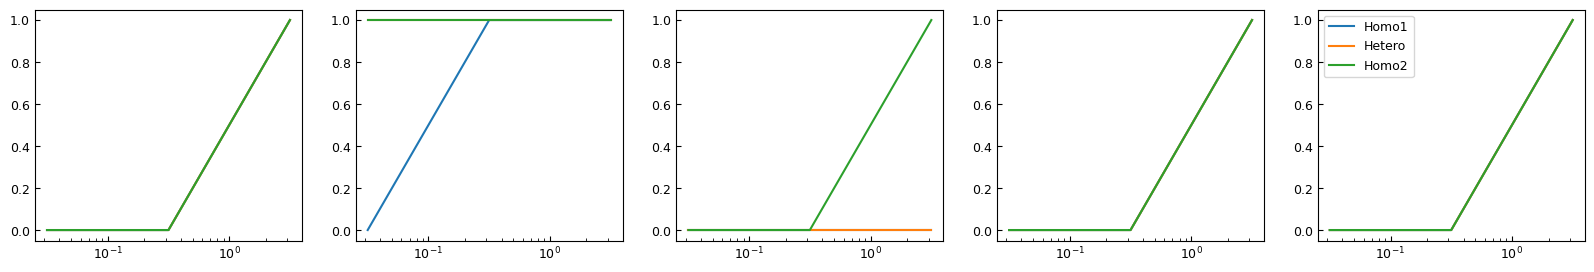

In [103]:
# Plot the activity curves generated
i = 1
print('---------------HOMO 1---------------')
print(f'Kcs = {Kcs[i,0]}')
print(f'Kos = {Kos[i,0]}')
print(f'eps = {epsilon[i,0]}')
print('---------------HETERO ---------------')
print(f'Kcs = {Kcs[i,1]}')
print(f'Kos = {Kos[i,1]}')
print(f'eps = {epsilon[i,1]}')
print('---------------HOMO 2---------------')
print(f'Kcs = {Kcs[i,2]}')
print(f'Kos = {Kos[i,2]}')
print(f'eps = {epsilon[i,2]}')

fig,ax = plt.subplots(ncols=5, figsize=(5*4,3))
for i in range(5):
    ax[i].plot(c_centers,A[i,0],label='Homo1')
    ax[i].plot(c_centers,A[i,1],label='Hetero')
    ax[i].plot(c_centers,A[i,2],label='Homo2')
    ax[i].set_xscale('log')

plt.legend()

In [105]:
analyze_activity_histogram_and_mi(A,Na)

(np.float64(1.1957124991003294),
 array([144,  23,  46,  87]),
 array([0.48      , 0.07666667, 0.15333333, 0.29      ]))